# Week4
## Strict Fixed-Baseline-Template Sorting on Compressed-Reconstructed Data

This notebook performs strict sorting on compressed data using baseline templates only.
No baseline spike-time candidate anchoring is used for sorting.


In [1]:
import gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from kilosort import template_matching as ks_tm

ROOT = Path('F:/academic')
DATA_ROOT = ROOT / '.test_data'
BASE_RESULTS = DATA_ROOT / 'kilosort4'

compressed_bin = ROOT / 'whitened_recon_ratio_0.10.bin'
if not compressed_bin.exists():
    compressed_bin = ROOT / 'whitened_recon_ratio_0.20.bin'
if not compressed_bin.exists():
    raise FileNotFoundError('Missing whitened_recon_ratio_*.bin')

print('Compressed bin:', compressed_bin)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


Compressed bin: F:\academic\whitened_recon_ratio_0.10.bin
device: cuda


In [2]:
# Load baseline templates/results from uncompressed data
templates_base = np.load(BASE_RESULTS / 'templates.npy')  # [n_templates, nt, n_chan_tpl]
ops_base = np.load(BASE_RESULTS / 'ops.npy', allow_pickle=True).item()
st_base = np.load(BASE_RESULTS / 'spike_times.npy').squeeze().astype(np.int64)
clu_base = np.load(BASE_RESULTS / 'spike_clusters.npy').squeeze().astype(np.int64)

n_templates, nt, n_chan_tpl = templates_base.shape
print('templates_base shape:', templates_base.shape)

# Project data format: reconstructed compressed data is float32, 383 channels
data_dtype = np.float32
src_n_chan = 383
raw = np.memmap(compressed_bin, dtype=data_dtype, mode='r')
n_samples = raw.size // src_n_chan
data_cmp = raw[: n_samples * src_n_chan].reshape(n_samples, src_n_chan)
n_use = min(n_chan_tpl, src_n_chan)
templates_fixed = templates_base[:, :, :n_use].astype(np.float32, copy=False)
print('compressed data shape:', data_cmp.shape, '| channels used:', n_use)


templates_base shape: (267, 61, 383)
compressed data shape: (1350000, 383) | channels used: 383


### Note: 383 vs 385 channels
Baseline runs may use full probe channel definitions (e.g., including extra/sync/reference channels).
Compressed reconstructed data here has 383 channels; fixed-template matching uses shared channels only.


In [3]:
# Prepare Kilosort fixed-template matching objects on GPU/CPU
for _name in ['U', 'ctc', 'wPCA_t', 'tpl_t', 'X']:
    if _name in globals():
        try:
            del globals()[_name]
        except Exception:
            pass
gc.collect()
if device.type == 'cuda':
    try:
        torch.cuda.empty_cache()
    except Exception:
        pass

ops_tm = dict(ops_base)
ops_tm['settings'] = dict(ops_base.get('settings', {}))
ops_tm['nt'] = int(nt)
ops_tm['nt0min'] = int(ops_base.get('nt0min', nt//2))
ops_tm['Th_learned'] = float(ops_base.get('Th_learned', 8))
ops_tm['max_peels'] = int(ops_base.get('max_peels', 8))

wPCA = ops_base.get('wPCA', None)
if wPCA is None:
    raise RuntimeError('ops_base does not contain wPCA required by template_matching.run_matching')
wPCA_t = torch.from_numpy(np.asarray(wPCA, dtype=np.float32)).to(device=device).contiguous()
ops_tm['wPCA'] = wPCA_t

tpl_t = torch.as_tensor(templates_fixed, dtype=torch.float32, device=device)
# [u,t,c] x [p,t] -> [u,p,c]
U = torch.einsum('utc,pt->upc', tpl_t, wPCA_t).contiguous()
del tpl_t

ctc = ks_tm.prepare_matching(ops_tm, U)
print('wPCA:', tuple(wPCA_t.shape), 'U:', tuple(U.shape), 'ctc:', tuple(ctc.shape))


wPCA: (6, 61) U: (267, 6, 383) ctc: (267, 267, 123)


In [4]:
# Strict sorting on full compressed timeline (no baseline candidate anchoring)
win = 12000   # reduce if OOM
overlap = nt * 2

all_t = []
all_k = []
all_amp = []
all_th = []

for t0 in range(0, n_samples, win):
    t1 = min(n_samples, t0 + win)
    # local context padding for edge-stable matching
    x0 = max(0, t0 - overlap)
    x1 = min(n_samples, t1 + overlap)
    if (x1 - x0) < nt:
        continue

    X_np = np.array(data_cmp[x0:x1, :n_use].T, dtype=np.float32, copy=True)
    X = torch.from_numpy(X_np).to(device=device, non_blocking=True).contiguous()

    with torch.no_grad():
        stt, amps, th_amps, _ = ks_tm.run_matching(ops_tm, X, U, ctc, device=device)

    t_abs = stt[:,0].detach().cpu().numpy().astype(np.int64) + x0
    k_abs = stt[:,1].detach().cpu().numpy().astype(np.int64)
    a_abs = amps.detach().cpu().numpy().squeeze()
    h_abs = th_amps.detach().cpu().numpy().squeeze()

    # keep only center region to avoid duplicate detections across overlapping windows
    keep = (t_abs >= t0) & (t_abs < t1)
    if np.any(keep):
        all_t.append(t_abs[keep])
        all_k.append(k_abs[keep])
        all_amp.append(a_abs[keep])
        all_th.append(h_abs[keep])

    del X
    if device.type == 'cuda':
        torch.cuda.empty_cache()

if len(all_t) == 0:
    st_cmp_fixed = np.empty((0,), dtype=np.int64)
    clu_cmp_fixed = np.empty((0,), dtype=np.int64)
    amp_cmp_fixed = np.empty((0,), dtype=np.float32)
    th_cmp_fixed = np.empty((0,), dtype=np.float32)
else:
    st_cmp_fixed = np.concatenate(all_t)
    clu_cmp_fixed = np.concatenate(all_k)
    amp_cmp_fixed = np.concatenate(all_amp)
    th_cmp_fixed = np.concatenate(all_th)

    # global time sort
    order = np.argsort(st_cmp_fixed)
    st_cmp_fixed = st_cmp_fixed[order]
    clu_cmp_fixed = clu_cmp_fixed[order]
    amp_cmp_fixed = amp_cmp_fixed[order]
    th_cmp_fixed = th_cmp_fixed[order]

print('strict sorted spikes:', st_cmp_fixed.shape[0])
print('unique predicted templates:', np.unique(clu_cmp_fixed).shape[0] if st_cmp_fixed.size else 0)


strict sorted spikes: 123348
unique predicted templates: 265


In [5]:
# Save strict fixed-template sort output
out = {
    'compressed_bin': str(compressed_bin),
    'method': 'strict_kilosort_run_matching_fixed_baseline_templates_full_timeline',
    'st': st_cmp_fixed,
    'clu': clu_cmp_fixed,
    'amp': amp_cmp_fixed,
    'th_amp': th_cmp_fixed,
    'template_shape': templates_fixed.shape,
    'compressed_shape': data_cmp.shape,
}
np.save(ROOT / 'week4_kilosort_function_fixed_template_results.npy', out, allow_pickle=True)
print('saved:', ROOT / 'week4_kilosort_function_fixed_template_results.npy')


saved: F:\academic\week4_kilosort_function_fixed_template_results.npy


## Result Analysis (Evaluation Only)
Baseline data is used only for evaluation alignment, not for candidate selection during sorting.


In [6]:
# Time-alignment evaluation: strict sort result -> nearest baseline spike
tol = 12
baseline_st = st_base.astype(np.int64)
baseline_clu = clu_base.astype(np.int64)
test_st = st_cmp_fixed.astype(np.int64)
test_clu = clu_cmp_fixed.astype(np.int64)

if test_st.size == 0 or baseline_st.size == 0:
    labels = np.empty((0,), dtype=np.int64)
    matched = np.empty((0,), dtype=bool)
else:
    pos = np.searchsorted(baseline_st, test_st)
    left = np.clip(pos-1, 0, baseline_st.size-1)
    right = np.clip(pos, 0, baseline_st.size-1)
    dl = np.abs(test_st - baseline_st[left])
    dr = np.abs(test_st - baseline_st[right])
    use_l = dl <= dr
    nn = np.where(use_l, left, right)
    dt = np.abs(test_st - baseline_st[nn])
    matched = dt <= tol
    labels = np.full(test_st.shape[0], -1, dtype=np.int64)
    labels[matched] = baseline_clu[nn[matched]]

coverage_vs_baseline = matched.mean() if matched.size else 0.0
print(f'Matched to baseline within +/-{tol} samples: {matched.sum()} / {matched.size} ({coverage_vs_baseline*100:.2f}%)')

if matched.any():
    acc = (test_clu[matched] == labels[matched]).mean()
    print(f'Label agreement on matched spikes: {acc*100:.2f}%')
else:
    print('No matched spikes for label comparison.')


Matched to baseline within +/-12 samples: 121700 / 123348 (98.66%)
Label agreement on matched spikes: 12.55%


In [7]:
# Cluster-level summary on matched spikes
if matched.size == 0:
    summary = pd.DataFrame(columns=['baseline_clu','n_ref','n_matched_from_test','recall_from_test_side','same_label_rate'])
else:
    dfm = pd.DataFrame({
        'test_st': test_st,
        'test_clu': test_clu,
        'baseline_clu': labels,
        'matched': matched,
    })

    ref_counts = pd.Series(baseline_clu).value_counts().sort_index()
    m = dfm[dfm['matched']].copy()
    g = m.groupby('baseline_clu')
    n_matched = g.size()
    same_rate = g.apply(lambda x: (x['test_clu'].values == x['baseline_clu'].values).mean())

    summary = pd.DataFrame({
        'baseline_clu': ref_counts.index.values,
        'n_ref': ref_counts.values,
    })
    summary = summary.merge(n_matched.rename('n_matched_from_test'), left_on='baseline_clu', right_index=True, how='left')
    summary = summary.merge(same_rate.rename('same_label_rate'), left_on='baseline_clu', right_index=True, how='left')
    summary['n_matched_from_test'] = summary['n_matched_from_test'].fillna(0).astype(int)
    summary['recall_from_test_side'] = summary['n_matched_from_test'] / summary['n_ref']

display(summary.sort_values('n_ref', ascending=False).head(20))


C:\Users\baipi\AppData\Local\Temp\ipykernel_8828\1015573620.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  same_rate = g.apply(lambda x: (x['test_clu'].values == x['baseline_clu'].values).mean())


,baseline_clu,n_ref,n_matched_from_test,same_label_rate,recall_from_test_side
94,94,4211,2848,0.003160,0.676324
86,86,4139,2822,0.000000,0.681807
32,32,2649,2089,0.044998,0.788599
131,131,1752,1582,0.185841,0.902968
254,254,1599,1453,0.089470,0.908693
238,238,1503,1535,0.221498,1.021291
4,4,1464,1142,0.082312,0.780055
111,111,1354,1159,0.101812,0.855982
3,3,1351,1181,0.108383,0.874167
231,231,1351,1215,0.123457,0.899334


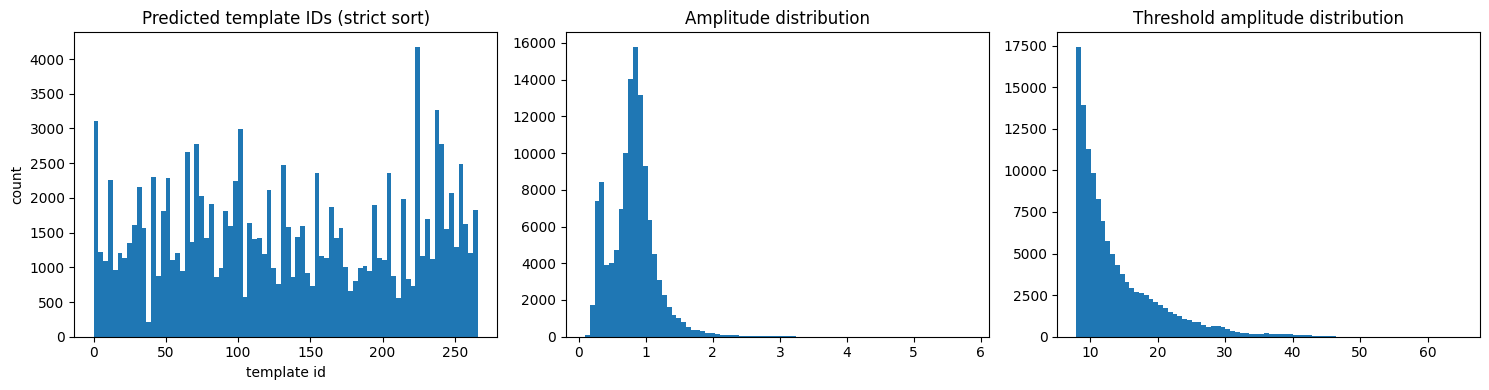

saved: F:\academic\week4_fixed_template_cluster_summary.csv


In [8]:
# Distributions and export
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

if st_cmp_fixed.size:
    ax[0].hist(clu_cmp_fixed, bins=80)
ax[0].set_title('Predicted template IDs (strict sort)')
ax[0].set_xlabel('template id')
ax[0].set_ylabel('count')

amp_ok = np.isfinite(amp_cmp_fixed)
if np.any(amp_ok):
    ax[1].hist(amp_cmp_fixed[amp_ok], bins=80)
ax[1].set_title('Amplitude distribution')

th_ok = np.isfinite(th_cmp_fixed)
if np.any(th_ok):
    ax[2].hist(th_cmp_fixed[th_ok], bins=80)
ax[2].set_title('Threshold amplitude distribution')

plt.tight_layout()
plt.show()

summary.to_csv(ROOT / 'week4_fixed_template_cluster_summary.csv', index=False)
print('saved:', ROOT / 'week4_fixed_template_cluster_summary.csv')


## Multi-Ratio Comparison (0.10 / 0.20 / 0.30 / 0.50 / 0.70)
If a reconstructed bin is missing, generate it from `whitened_data.npy` using DCT keep-ratio compression + IDCT reconstruction.


In [15]:
from scipy.fftpack import dct, idct
from datetime import datetime
import os
import time

def get_baseline_valid_chan_map(stored_baseline_res=None):
    if stored_baseline_res is None:
        br = np.load(ROOT / 'baseline_results.npy', allow_pickle=True).item()
    else:
        br = stored_baseline_res

    if 'probe' in br['ops'] and 'chanMap' in br['ops']['probe']:
        valid_chan_map = np.asarray(br['ops']['probe']['chanMap']).reshape(-1).astype(np.int32)
    else:
        valid_chan_map = np.arange(len(np.asarray(br['xc']).reshape(-1)), dtype=np.int32)
    return valid_chan_map

def align_whitened_to_baseline_channels(whitened_data, valid_chan_map):
    if whitened_data.shape[1] > len(valid_chan_map):
        return whitened_data[:, valid_chan_map]
    return whitened_data

def compress_whitened_to_coeff(whitened_data, keep_ratio, out_prefix='whitened_dct'):
    n_samples, n_chan = whitened_data.shape
    n_keep = max(1, int(n_samples * keep_ratio))
    # Unique filename each run to avoid Windows mmap overwrite lock
    ts = datetime.now().strftime('%Y%m%d_%H%M%S_%f')
    coeff_path = ROOT / f'{out_prefix}_ratio_{keep_ratio:.2f}_coeff_rebuild_{ts}.npy'

    coeff_mm = np.memmap(str(coeff_path), dtype='float32', mode='w+', shape=(n_keep, n_chan))
    for ch in range(n_chan):
        c = dct(whitened_data[:, ch].astype(np.float32, copy=False), norm='ortho')
        coeff_mm[:, ch] = c[:n_keep].astype('float32', copy=False)
    coeff_mm.flush()
    del coeff_mm
    return coeff_path, n_keep

def _release_bin_readers(bin_path):
    target = Path(bin_path).resolve()
    released = []
    for name in ('raw', 'data_cmp'):
        obj = globals().get(name, None)
        base = getattr(obj, 'base', None)
        mm = obj if isinstance(obj, np.memmap) else (base if isinstance(base, np.memmap) else None)
        if mm is None:
            continue
        try:
            if Path(mm.filename).resolve() == target:
                del globals()[name]
                released.append(name)
        except Exception:
            pass
    gc.collect()
    return released

def decompress_coeff_to_bin(coeff_path, n_samples, n_chan, n_keep, out_bin, retries=10, delay_s=0.2):
    out_bin = Path(out_bin)
    tmp_bin = out_bin.with_suffix(out_bin.suffix + '.tmp')

    coeff_mm = np.memmap(str(coeff_path), dtype='float32', mode='r', shape=(n_keep, n_chan))
    recon_mm = np.memmap(str(tmp_bin), dtype='float32', mode='w+', shape=(n_samples, n_chan))

    for ch in range(n_chan):
        c_full = np.zeros(n_samples, dtype='float32')
        c_full[:n_keep] = coeff_mm[:, ch]
        recon_mm[:, ch] = idct(c_full, norm='ortho').astype('float32', copy=False)

    recon_mm.flush()
    del coeff_mm, recon_mm
    gc.collect()

    _release_bin_readers(out_bin)

    last_err = None
    for _ in range(retries):
        try:
            os.replace(tmp_bin, out_bin)
            return out_bin
        except PermissionError as e:
            last_err = e
            time.sleep(delay_s)

    raise PermissionError(f'Failed to replace {out_bin} after {retries} retries; file is still in use.') from last_err

def ensure_recon_bin_for_ratio(keep_ratio, whitened_data=None, force_rebuild=False):
    recon_bin = ROOT / f'whitened_recon_ratio_{keep_ratio:.2f}.bin'
    if recon_bin.exists() and (not force_rebuild):
        print(f'[ratio={keep_ratio:.2f}] using existing: {recon_bin.name}')
        return recon_bin

    if whitened_data is None:
        wp = ROOT / 'whitened_data.npy'
        if not wp.exists():
            raise FileNotFoundError('whitened_data.npy is required to generate missing recon bins.')
        whitened_data = np.load(wp, mmap_mode='r')

    valid_chan_map = get_baseline_valid_chan_map()
    whitened_aligned = align_whitened_to_baseline_channels(whitened_data, valid_chan_map)

    print(f'[ratio={keep_ratio:.2f}] generating with unified channel standard: {whitened_aligned.shape[1]} channels')
    coeff_path, n_keep = compress_whitened_to_coeff(whitened_aligned, keep_ratio, out_prefix='whitened_dct')
    recon_bin = decompress_coeff_to_bin(
        coeff_path=coeff_path,
        n_samples=whitened_aligned.shape[0],
        n_chan=whitened_aligned.shape[1],
        n_keep=n_keep,
        out_bin=recon_bin
    )
    print(f'[ratio={keep_ratio:.2f}] generated: {recon_bin.name}')
    return recon_bin


In [16]:
def infer_src_n_chan_from_bin(bin_path, dtype=np.float32, candidates=(383, 385)):
    size = Path(bin_path).stat().st_size
    item = np.dtype(dtype).itemsize
    ok = []
    for ch in candidates:
        if size % (ch * item) == 0:
            ok.append(ch)
    if not ok:
        raise ValueError(f'Cannot infer channel count for {bin_path} from size={size}.')
    # Prefer 383 for backward compatibility if both somehow divide.
    return 383 if 383 in ok else ok[0]

def classify_at_baseline_times(bin_path, st_base_eval, U, ctc, ops_tm, n_use, nt, device):
    """Classify compressed data at baseline spike times only (no test->baseline remapping)."""
    data_dtype = np.float32
    src_n_chan = infer_src_n_chan_from_bin(bin_path, dtype=data_dtype, candidates=(383, 385))
    raw = np.memmap(bin_path, dtype=data_dtype, mode='r')
    n_samples_local = raw.size // src_n_chan
    data_cmp_local = raw[: n_samples_local * src_n_chan].reshape(n_samples_local, src_n_chan)

    # Use only overlapping channels with baseline template channels
    n_use_local = min(n_use, src_n_chan)

    half = nt // 2
    valid = (st_base_eval - half >= 0) & (st_base_eval + (nt - half) <= n_samples_local)
    st_valid = st_base_eval[valid].astype(np.int64)

    pred = np.full(st_valid.shape[0], -1, dtype=np.int64)
    chunk = 4000

    for s in range(0, st_valid.shape[0], chunk):
        idx = np.arange(s, min(s + chunk, st_valid.shape[0]))
        t_idx = st_valid[idx]
        t0 = max(0, int(t_idx.min()) - nt)
        t1 = min(n_samples_local, int(t_idx.max()) + nt + 1)
        if (t1 - t0) < nt:
            continue

        X_np = np.array(data_cmp_local[t0:t1, :n_use_local].T, dtype=np.float32, copy=True)
        X = torch.from_numpy(X_np).to(device=device, non_blocking=True).contiguous()
        with torch.no_grad():
            stt, _, _, _ = ks_tm.run_matching(ops_tm, X, U[:, :, :n_use_local], ctc, device=device)

        det_t = stt[:, 0].detach().cpu().numpy().astype(np.int64) + t0
        det_k = stt[:, 1].detach().cpu().numpy().astype(np.int64)

        if det_t.size > 0:
            pos = np.searchsorted(det_t, t_idx)
            left = np.clip(pos - 1, 0, det_t.size - 1)
            right = np.clip(pos, 0, det_t.size - 1)
            dl = np.abs(t_idx - det_t[left])
            dr = np.abs(t_idx - det_t[right])
            nn = np.where(dl <= dr, left, right)
            d = np.abs(t_idx - det_t[nn])
            ok = d <= 12
            pred[idx[ok]] = det_k[nn[ok]]

        del X
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    return st_valid, pred, valid

def eval_same_event_accuracy(bin_path, st_base_eval, clu_base_eval, U, ctc, ops_tm, n_use, nt, device):
    st_valid, pred, valid_mask = classify_at_baseline_times(bin_path, st_base_eval, U, ctc, ops_tm, n_use, nt, device)
    clu_valid = clu_base_eval[valid_mask].astype(np.int64)

    detected = pred >= 0
    detection_rate = detected.mean() if detected.size else 0.0
    if detected.any():
        classification_accuracy = (pred[detected] == clu_valid[detected]).mean()
        overall_same_event_accuracy = (pred[detected] == clu_valid[detected]).sum() / max(len(clu_valid), 1)
    else:
        classification_accuracy = np.nan
        overall_same_event_accuracy = 0.0

    return {
        'n_baseline_events': int(len(clu_valid)),
        'n_detected_events': int(detected.sum()),
        'detection_rate_on_baseline_events': float(detection_rate),
        'classification_accuracy_on_detected_events': float(classification_accuracy) if np.isfinite(classification_accuracy) else np.nan,
        'overall_same_event_accuracy': float(overall_same_event_accuracy),
    }


In [17]:
# Execute same-event evaluation and output results
ratios = [0.10, 0.20, 0.30, 0.50, 0.70]
rows = []
whitened_for_build = None
if any(not (ROOT / f'whitened_recon_ratio_{r:.2f}.bin').exists() for r in ratios):
    wp = ROOT / 'whitened_data.npy'
    if not wp.exists():
        raise FileNotFoundError('Missing ratio bin(s) and missing whitened_data.npy for reconstruction.')
    whitened_for_build = np.load(wp, mmap_mode='r')
for r in ratios:
    bp = ensure_recon_bin_for_ratio(r, whitened_data=whitened_for_build, force_rebuild=True)
    ch = infer_src_n_chan_from_bin(bp, dtype=np.float32, candidates=(383,385))
    print(f'ratio={r:.2f} uses src_n_chan={ch}')
    m = eval_same_event_accuracy(bp, st_base, clu_base, U, ctc, ops_tm, n_use, nt, device)
    m['ratio'] = f'{r:.2f}'
    rows.append(m)
compare_df = pd.DataFrame(rows)[[
    'ratio',
    'n_baseline_events',
    'n_detected_events',
    'detection_rate_on_baseline_events',
    'classification_accuracy_on_detected_events',
    'overall_same_event_accuracy',
]]
# user-facing output
display(compare_df)
for _, r in compare_df.iterrows():
    ratio = r['ratio']
    det = r['detection_rate_on_baseline_events'] * 100
    cls = r['classification_accuracy_on_detected_events'] * 100 if np.isfinite(r['classification_accuracy_on_detected_events']) else np.nan
    ov = r['overall_same_event_accuracy'] * 100
    print(f"ratio={ratio} | detection={det:.2f}% | classification={cls:.2f}% | overall={ov:.2f}%")
compare_df.to_csv(ROOT / 'week4_fixed_template_ratio_compare.csv', index=False)
print('saved:', ROOT / 'week4_fixed_template_ratio_compare.csv')


[ratio=0.10] generating with unified channel standard: 383 channels
[ratio=0.10] generated: whitened_recon_ratio_0.10.bin
ratio=0.10 uses src_n_chan=383
[ratio=0.20] generating with unified channel standard: 383 channels
[ratio=0.20] generated: whitened_recon_ratio_0.20.bin
ratio=0.20 uses src_n_chan=383
[ratio=0.30] generating with unified channel standard: 383 channels
[ratio=0.30] generated: whitened_recon_ratio_0.30.bin
ratio=0.30 uses src_n_chan=383
[ratio=0.50] generating with unified channel standard: 383 channels
[ratio=0.50] generated: whitened_recon_ratio_0.50.bin
ratio=0.50 uses src_n_chan=383
[ratio=0.70] generating with unified channel standard: 383 channels
[ratio=0.70] generated: whitened_recon_ratio_0.70.bin
ratio=0.70 uses src_n_chan=383


,ratio,n_baseline_events,n_detected_events,detection_rate_on_baseline_events,classification_accuracy_on_detected_events,overall_same_event_accuracy
0,0.10,137378,15848,0.115361,0.238264,0.027486
1,0.20,137378,15570,0.113337,0.235710,0.026715
2,0.30,137378,15583,0.113432,0.233331,0.026467
3,0.50,137378,15896,0.115710,0.233140,0.026977
4,0.70,137378,15938,0.116016,0.233906,0.027137


ratio=0.10 | detection=11.54% | classification=23.83% | overall=2.75%
ratio=0.20 | detection=11.33% | classification=23.57% | overall=2.67%
ratio=0.30 | detection=11.34% | classification=23.33% | overall=2.65%
ratio=0.50 | detection=11.57% | classification=23.31% | overall=2.70%
ratio=0.70 | detection=11.60% | classification=23.39% | overall=2.71%
saved: F:\academic\week4_fixed_template_ratio_compare.csv
